GeoVisionAI – Population Prediction (2021–2025 → 2026)

## Objective
To predict the population of a selected Indian city or village for the year 2026 using authentic population estimates from 2021–2025 and a machine-learning forecasting model.

## Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Google Colab

## 2. Import Libraries

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


Test Internet/API connection

In [ ]:
API_URL = "https://api.worldpop.org/v2"

response = requests.get(API_URL)

print("Status Code:", response.status_code)

Status Code: 200


In [ ]:
!pip -q install geopy

In [ ]:
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="GeoVisionAI")

location = geolocator.geocode("Kolhapur, Maharashtra, India")

print("Location:", location.address)
print("Latitude:", location.latitude)
print("Longitude:", location.longitude)

Location: Kolhapur, Karvir, Kolhapur, Maharashtra, 416003, India
Latitude: 16.7028412
Longitude: 74.2405329


In [ ]:
import requests

url = "https://nominatim.openstreetmap.org/search"

params = {
    "q": "Kolhapur, Maharashtra, India",
    "format": "json",
    "polygon_geojson": 1,
    "limit": 1
}

headers = {
    "User-Agent": "GeoVisionAI/1.0"
}

response = requests.get(url, params=params, headers=headers)

print("Status Code:", response.status_code)

data = response.json()

print("Number of results:", len(data))

if data:
    print("Name:", data[0]["display_name"])
    print("Type:", data[0]["type"])
    print("Class:", data[0]["class"])
    print("Has boundary:", "geojson" in data[0])

Status Code: 200
Number of results: 1
Name: Kolhapur, Karvir, Kolhapur, Maharashtra, 416003, India
Type: city
Class: place
Has boundary: True


In [ ]:
import requests
import json

url = "https://nominatim.openstreetmap.org/search"

params = {
    "q": "Kolhapur Municipal Corporation, Maharashtra, India",
    "format": "geojson",
    "polygon_geojson": 1,
    "limit": 1
}

headers = {
    "User-Agent": "GeoVisionAI-Population-Project/1.0"
}

response = requests.get(url, params=params, headers=headers)

print("Status Code:", response.status_code)

result = response.json()

print("Number of results:", len(result["features"]))

if result["features"]:
    feature = result["features"][0]

    print("Name:", feature["properties"].get("display_name"))
    print("Geometry type:", feature["geometry"]["type"])

Status Code: 200
Number of results: 1
Name: Kolhapur Municipal Corporation, Bhausinghji Road, Shaniwar Peth, Kolhapur, Karvir, Kolhapur, Maharashtra, 416002, India
Geometry type: Polygon


In [ ]:
kolhapur_boundary = result["features"][0]["geometry"]

print("Geometry type:", kolhapur_boundary["type"])
print("Kolhapur boundary successfully saved!")

Geometry type: Polygon
Kolhapur boundary successfully saved!


In [ ]:
WORLDPOP_URL = "https://api.worldpop.org/v2/population"

payload = {
    "geojson": kolhapur_boundary,
    "year": 2021,
    "resolution": "100m"
}

response = requests.post(
    WORLDPOP_URL,
    json=payload
)

print("Status Code:", response.status_code)
print(response.json())

Status Code: 200
{'task_id': 'b46ec3c6-5e41-4051-b0c9-28ed3789d5a6', 'status': 'pending', 'message': 'Population calculation task submitted successfully', 'check_url': '/api/v1/tasks/b46ec3c6-5e41-4051-b0c9-28ed3789d5a6'}


In [ ]:
task_id = "b46ec3c6-5e41-4051-b0c9-28ed3789d5a6"

status_url = f"https://api.worldpop.org/v2/tasks/{task_id}"

response = requests.get(status_url)

print("Status Code:", response.status_code)
print(response.json())

Status Code: 200
{'task_id': 'b46ec3c6-5e41-4051-b0c9-28ed3789d5a6', 'status': 'failure', 'progress': 100.0, 'stage': 'Failed', 'result': None, 'error': 'Error calculating pixel coordinates: Invalid raster window dimensions: dx=0, dy=1'}


In [ ]:
!pip -q install rasterio geopandas shapely

In [ ]:
import geopandas as gpd
from shapely.geometry import shape

kolhapur_shape = shape(kolhapur_boundary)

print("Geometry:", kolhapur_shape.geom_type)
print("Valid:", kolhapur_shape.is_valid)
print("Area:", kolhapur_shape.area)

Geometry: Polygon
Valid: True
Area: 2.1559641999979778e-07


In [ ]:
import requests

# Official WorldPop 2021 India 100m data directory
url = "https://data.worldpop.org/GIS/Population/Global_2015_2030/R2025A/2021/IND/v1/100m/"

r = requests.get(url)

print("Status:", r.status_code)
print(r.text[:2000])

Status: 200
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN"
"http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">
<html xmlns="http://www.w3.org/1999/xhtml">
 <head>
  <title>Index of /GIS/Population/Global_2015_2030/R2025A/2021/IND/v1/100m</title>
 </head>
 <body>
<h1>Index of /GIS/Population/Global_2015_2030/R2025A/2021/IND/v1/100m</h1>
  <table>
   <tr><th valign="top"><img src="/icons/blank.gif" alt="[ICO]" /></th><th><a href="?C=N;O=D">Name</a></th><th><a href="?C=M;O=A">Last modified</a></th><th><a href="?C=S;O=A">Size</a></th><th><a href="?C=D;O=A">Description</a></th></tr>
   <tr><th colspan="5"><hr /></th></tr>
<tr><td valign="top"><img src="/icons/back.gif" alt="[PARENTDIR]" /></td><td><a href="/GIS/Population/Global_2015_2030/R2025A/2021/IND/v1/">Parent Directory</a></td><td>&nbsp;</td><td align="right">  - </td><td>&nbsp;</td></tr>
<tr><td valign="top"><img src="/icons/folder.gif" alt="[DIR]" /></td><td><a href="constrained/">constrained/</a></td><td ali

In [ ]:
url = "https://data.worldpop.org/GIS/Population/Global_2015_2030/R2025A/2021/IND/v1/100m/constrained/"

r = requests.get(url)

print("Status:", r.status_code)
print(r.text[:5000])

Status: 200
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN"
"http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">
<html xmlns="http://www.w3.org/1999/xhtml">
 <head>
  <title>Index of /GIS/Population/Global_2015_2030/R2025A/2021/IND/v1/100m/constrained</title>
 </head>
 <body>
<h1>Index of /GIS/Population/Global_2015_2030/R2025A/2021/IND/v1/100m/constrained</h1>
  <table>
   <tr><th valign="top"><img src="/icons/blank.gif" alt="[ICO]" /></th><th><a href="?C=N;O=D">Name</a></th><th><a href="?C=M;O=A">Last modified</a></th><th><a href="?C=S;O=A">Size</a></th><th><a href="?C=D;O=A">Description</a></th></tr>
   <tr><th colspan="5"><hr /></th></tr>
<tr><td valign="top"><img src="/icons/back.gif" alt="[PARENTDIR]" /></td><td><a href="/GIS/Population/Global_2015_2030/R2025A/2021/IND/v1/100m/">Parent Directory</a></td><td>&nbsp;</td><td align="right">  - </td><td>&nbsp;</td></tr>
<tr><td valign="top"><img src="/icons/image2.gif" alt="[IMG]" /></td><td><a href="ind_pop_2021_

In [ ]:
import requests
from pathlib import Path

url = "https://data.worldpop.org/GIS/Population/Global_2015_2030/R2025A/2021/IND/v1/100m/constrained/ind_pop_2021_CN_100m_R2025A_v1.tif"

output_file = "/content/ind_pop_2021_CN_100m_R2025A_v1.tif"

print("Downloading 2021 India population raster...")

with requests.get(url, stream=True) as response:
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))
    downloaded = 0

    with open(output_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)

                if total_size:
                    percent = downloaded / total_size * 100
                    print(f"\rDownloaded: {percent:.1f}%", end="")

print("\n✅ 2021 population raster downloaded!")
print("File:", output_file)

Downloaded: 100.0%
✅ 2021 population raster downloaded!
File: /content/ind_pop_2021_CN_100m_R2025A_v1.tif


In [ ]:
import rasterio

raster_path = "/content/ind_pop_2021_CN_100m_R2025A_v1.tif"

with rasterio.open(raster_path) as src:
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)

CRS: EPSG:4326
Width: 35040
Height: 34507
Resolution: (0.00083333333, 0.00083333333)
NoData: -99999.0


In [ ]:
import geopandas as gpd
from shapely.geometry import shape
import rasterio
from rasterio.mask import mask

# Convert our Kolhapur boundary into a GeoDataFrame
kolhapur_gdf = gpd.GeoDataFrame(
    {"name": ["Kolhapur Municipal Corporation"]},
    geometry=[shape(kolhapur_boundary)],
    crs="EPSG:4326"
)

# Open WorldPop raster
with rasterio.open(raster_path) as src:

    # Clip raster using Kolhapur boundary
    clipped, transform = mask(
        src,
        kolhapur_gdf.geometry,
        crop=True,
        nodata=src.nodata
    )

    population_pixels = clipped[0]

print("Clipped raster shape:", population_pixels.shape)
print("Number of pixels:", population_pixels.size)
print("Minimum value:", population_pixels[population_pixels != -99999].min())
print("Maximum value:", population_pixels[population_pixels != -99999].max())

Clipped raster shape: (2, 1)
Number of pixels: 2
Minimum value: 125.55263
Maximum value: 125.55263


In [ ]:
print("Kolhapur boundary bounds:")
print(kolhapur_shape.bounds)

print("\nApproximate area in degrees²:")
print(kolhapur_shape.area)

Kolhapur boundary bounds:
(74.2237123, 16.6982675, 74.2241377, 16.6987934)

Approximate area in degrees²:
2.1559641999979778e-07


In [ ]:
import requests
import json

overpass_url = "https://overpass-api.de/api/interpreter"

query = """
[out:json][timeout:60];

area["name"="Kolhapur"]["boundary"="administrative"]->.searchArea;

(
  relation
    ["boundary"="administrative"]
    ["name"="Kolhapur Municipal Corporation"]
    (area.searchArea);

  way
    ["boundary"="administrative"]
    ["name"="Kolhapur Municipal Corporation"]
    (area.searchArea);
);

out geom;
"""

response = requests.post(
    overpass_url,
    data=query,
    headers={"User-Agent": "GeoVisionAI-Population-Project/1.0"}
)

print("Status Code:", response.status_code)

data = response.json()

print("Number of results:", len(data["elements"]))

for element in data["elements"]:
    print(
        "Type:", element["type"],
        "| ID:", element["id"],
        "| Name:", element.get("tags", {}).get("name")
    )

Status Code: 504


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import requests

url = "https://raw.githubusercontent.com/datameet/maps/master/Municipalities/Maharashtra/Kolhapur.geojson"

response = requests.get(url)

print("Status Code:", response.status_code)
print("Content Type:", response.headers.get("content-type"))
print("Size:", len(response.content))

Status Code: 404
Content Type: text/plain; charset=utf-8
Size: 14


In [ ]:
import requests
import geopandas as gpd
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

query_url = "https://mapservice.gov.in/gismapservice/rest/services/BharatMapService/Admin_Boundary_District/MapServer/1/query"

params = {
    "where": "dtname='Kolhapur' AND stname='Maharashtra'",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}

response = requests.get(
    query_url,
    params=params,
    verify=False,
    timeout=60
)

print("Status Code:", response.status_code)

result = response.json()

print("Number of features:", len(result["features"]))

if len(result["features"]) > 0:

    kolhapur_district = gpd.GeoDataFrame.from_features(
        result["features"]
    )

    kolhapur_district = kolhapur_district.set_crs(
        "EPSG:4326",
        allow_override=True
    )

    print("District:", kolhapur_district.iloc[0]["dtname"])
    print("State:", kolhapur_district.iloc[0]["stname"])
    print("Geometry:", kolhapur_district.geometry.iloc[0].geom_type)
    print("Bounds:", kolhapur_district.total_bounds)

else:
    print("❌ Kolhapur district not found.")

Status Code: 200
Number of features: 1
District: Kolhapur
State: Maharashtra
Geometry: Polygon
Bounds: [73.68839291 15.74159136 74.70058072 17.18207754]


In [ ]:
# Convert Kolhapur District boundary to WorldPop's CRS
kolhapur_district = kolhapur_district.to_crs("EPSG:4326")

print("CRS:", kolhapur_district.crs)
print("Geometry:", kolhapur_district.geometry.iloc[0].geom_type)
print("Bounds:", kolhapur_district.total_bounds)

CRS: EPSG:4326
Geometry: Polygon
Bounds: [73.68839291 15.74159136 74.70058072 17.18207754]


In [ ]:
import rasterio
from rasterio.mask import mask
import numpy as np

# Path to your WorldPop 2021 raster
raster_path = "/content/ind_pop_2021_CN_100m_R2025A_v1.tif"

with rasterio.open(raster_path) as src:

    print("Raster CRS:", src.crs)
    print("Raster resolution:", src.res)

    # Convert district polygon to GeoJSON format
    shapes = [
        kolhapur_district.geometry.iloc[0].__geo_interface__
    ]

    # Clip raster using Kolhapur District boundary
    clipped, transform = mask(
        src,
        shapes,
        crop=True,
        nodata=0
    )

    population = clipped[0]

    # Remove invalid values
    valid_population = population[population > 0]

    print("Clipped raster shape:", population.shape)
    print("Number of valid pixels:", len(valid_population))

    # Calculate total population
    population_2021 = valid_population.sum()

print("\n================================")
print("Kolhapur District Population 2021")
print("================================")
print(f"{population_2021:,.0f}")

Raster CRS: EPSG:4326
Raster resolution: (0.00083333333, 0.00083333333)
Clipped raster shape: (1730, 1215)
Number of valid pixels: 350651

Kolhapur District Population 2021
3,703,980


In [ ]:
import requests

year = 2022

url = f"https://data.worldpop.org/GIS/Population/Global_2015_2030/R2025A/{year}/IND/v1/100m/constrained/ind_pop_{year}_CN_100m_R2025A_v1.tif"

output_file = f"/content/ind_pop_{year}_CN_100m_R2025A_v1.tif"

print(f"Downloading WorldPop India {year} raster...")

with requests.get(url, stream=True) as response:
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))
    downloaded = 0

    with open(output_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)

                if total_size:
                    percent = downloaded / total_size * 100
                    print(f"\rDownloaded: {percent:.1f}%", end="")

print(f"\n✅ {year} population raster downloaded!")
print("File:", output_file)

Downloaded: 100.0%
✅ 2022 population raster downloaded!
File: /content/ind_pop_2022_CN_100m_R2025A_v1.tif


In [ ]:
import rasterio

raster_2022 = "/content/ind_pop_2022_CN_100m_R2025A_v1.tif"

with rasterio.open(raster_2022) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)

CRS: EPSG:4326
Resolution: (0.00083333333, 0.00083333333)
NoData: -99999.0


In [ ]:
import rasterio
from rasterio.mask import mask
import numpy as np

raster_2022 = "/content/ind_pop_2022_CN_100m_R2025A_v1.tif"

with rasterio.open(raster_2022) as src:

    # Correct Kolhapur DISTRICT boundary
    shapes = [
        kolhapur_district.geometry.iloc[0].__geo_interface__
    ]

    # Clip raster to district boundary
    clipped, transform = mask(
        src,
        shapes,
        crop=True,
        nodata=0
    )

    population = clipped[0]

    # Keep only valid population values
    valid_population = population[population > 0]

    population_2022 = valid_population.sum()

    print("Raster CRS:", src.crs)
    print("Raster resolution:", src.res)
    print("Clipped raster shape:", population.shape)
    print("Number of valid pixels:", len(valid_population))

print("\n================================")
print("Kolhapur District Population 2022")
print("================================")
print(f"{population_2022:,.0f}")

Raster CRS: EPSG:4326
Raster resolution: (0.00083333333, 0.00083333333)
Clipped raster shape: (1730, 1215)
Number of valid pixels: 352264

Kolhapur District Population 2022
3,724,773


In [ ]:
import requests

year = 2023

url = f"https://data.worldpop.org/GIS/Population/Global_2015_2030/R2025A/{year}/IND/v1/100m/constrained/ind_pop_{year}_CN_100m_R2025A_v1.tif"

output_file = f"/content/ind_pop_{year}_CN_100m_R2025A_v1.tif"

print(f"Downloading WorldPop India {year} raster...")

with requests.get(url, stream=True) as response:
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))
    downloaded = 0

    with open(output_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)

                if total_size:
                    percent = downloaded / total_size * 100
                    print(f"\rDownloaded: {percent:.1f}%", end="")

print(f"\n✅ {year} population raster downloaded!")
print("File:", output_file)

Downloaded: 100.0%
✅ 2023 population raster downloaded!
File: /content/ind_pop_2023_CN_100m_R2025A_v1.tif


In [ ]:
import rasterio

raster_2023 = "/content/ind_pop_2023_CN_100m_R2025A_v1.tif"

with rasterio.open(raster_2023) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)

CRS: EPSG:4326
Resolution: (0.00083333333, 0.00083333333)
NoData: -99999.0


In [ ]:
import rasterio
from rasterio.mask import mask
import numpy as np

raster_2023 = "/content/ind_pop_2023_CN_100m_R2025A_v1.tif"

with rasterio.open(raster_2023) as src:

    shapes = [
        kolhapur_district.geometry.iloc[0].__geo_interface__
    ]

    clipped, transform = mask(
        src,
        shapes,
        crop=True,
        nodata=0
    )

    population = clipped[0]

    valid_population = population[population > 0]

    population_2023 = valid_population.sum()

    print("Raster CRS:", src.crs)
    print("Raster resolution:", src.res)
    print("Clipped raster shape:", population.shape)
    print("Number of valid pixels:", len(valid_population))

print("\n================================")
print("Kolhapur District Population 2023")
print("================================")
print(f"{population_2023:,.0f}")

Raster CRS: EPSG:4326
Raster resolution: (0.00083333333, 0.00083333333)
Clipped raster shape: (1730, 1215)
Number of valid pixels: 354954

Kolhapur District Population 2023
3,751,370


In [ ]:
import requests

year = 2024

url = f"https://data.worldpop.org/GIS/Population/Global_2015_2030/R2025A/{year}/IND/v1/100m/constrained/ind_pop_{year}_CN_100m_R2025A_v1.tif"

output_file = f"/content/ind_pop_{year}_CN_100m_R2025A_v1.tif"

print(f"Downloading WorldPop India {year} raster...")

with requests.get(url, stream=True) as response:
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))
    downloaded = 0

    with open(output_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)

                if total_size:
                    percent = downloaded / total_size * 100
                    print(f"\rDownloaded: {percent:.1f}%", end="")

print(f"\n✅ {year} population raster downloaded!")
print("File:", output_file)

Downloaded: 100.0%
✅ 2024 population raster downloaded!
File: /content/ind_pop_2024_CN_100m_R2025A_v1.tif


In [ ]:
import rasterio

raster_2024 = "/content/ind_pop_2024_CN_100m_R2025A_v1.tif"

with rasterio.open(raster_2024) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)

CRS: EPSG:4326
Resolution: (0.00083333333, 0.00083333333)
NoData: -99999.0


In [ ]:
import rasterio
from rasterio.mask import mask
import numpy as np

raster_2024 = "/content/ind_pop_2024_CN_100m_R2025A_v1.tif"

with rasterio.open(raster_2024) as src:

    shapes = [
        kolhapur_district.geometry.iloc[0].__geo_interface__
    ]

    clipped, transform = mask(
        src,
        shapes,
        crop=True,
        nodata=0
    )

    population = clipped[0]

    valid_population = population[population > 0]

    population_2024 = valid_population.sum()

    print("Raster CRS:", src.crs)
    print("Raster resolution:", src.res)
    print("Clipped raster shape:", population.shape)
    print("Number of valid pixels:", len(valid_population))

print("\n================================")
print("Kolhapur District Population 2024")
print("================================")
print(f"{population_2024:,.0f}")

Raster CRS: EPSG:4326
Raster resolution: (0.00083333333, 0.00083333333)
Clipped raster shape: (1730, 1215)
Number of valid pixels: 357830

Kolhapur District Population 2024
3,778,581


In [ ]:
import requests

year = 2025

url = f"https://data.worldpop.org/GIS/Population/Global_2015_2030/R2025A/{year}/IND/v1/100m/constrained/ind_pop_{year}_CN_100m_R2025A_v1.tif"

output_file = f"/content/ind_pop_{year}_CN_100m_R2025A_v1.tif"

print(f"Downloading WorldPop India {year} raster...")

with requests.get(url, stream=True) as response:
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))
    downloaded = 0

    with open(output_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)

                if total_size:
                    percent = downloaded / total_size * 100
                    print(f"\rDownloaded: {percent:.1f}%", end="")

print(f"\n✅ {year} population raster downloaded!")
print("File:", output_file)

Downloaded: 100.0%
✅ 2025 population raster downloaded!
File: /content/ind_pop_2025_CN_100m_R2025A_v1.tif


In [ ]:
import rasterio

raster_2025 = "/content/ind_pop_2025_CN_100m_R2025A_v1.tif"

with rasterio.open(raster_2025) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)

CRS: EPSG:4326
Resolution: (0.00083333333, 0.00083333333)
NoData: -99999.0


In [ ]:
import rasterio
from rasterio.mask import mask
import numpy as np

raster_2025 = "/content/ind_pop_2025_CN_100m_R2025A_v1.tif"

with rasterio.open(raster_2025) as src:

    shapes = [
        kolhapur_district.geometry.iloc[0].__geo_interface__
    ]

    clipped, transform = mask(
        src,
        shapes,
        crop=True,
        nodata=0
    )

    population = clipped[0]

    valid_population = population[population > 0]

    population_2025 = valid_population.sum()

    print("Raster CRS:", src.crs)
    print("Raster resolution:", src.res)
    print("Clipped raster shape:", population.shape)
    print("Number of valid pixels:", len(valid_population))

print("\n================================")
print("Kolhapur District Population 2025")
print("================================")
print(f"{population_2025:,.0f}")

Raster CRS: EPSG:4326
Raster resolution: (0.00083333333, 0.00083333333)
Clipped raster shape: (1730, 1215)
Number of valid pixels: 359472

Kolhapur District Population 2025
3,806,416


In [ ]:
import pandas as pd

population_data = pd.DataFrame({
    "Year": [2021, 2022, 2023, 2024, 2025],
    "Population": [
        population_2021,
        population_2022,
        population_2023,
        population_2024,
        population_2025
    ]
})

print(population_data)

   Year  Population
0  2021  3703979.50
1  2022  3724773.00
2  2023  3751369.50
3  2024  3778581.25
4  2025  3806416.25


In [ ]:
population_data.to_csv(
    "/content/kolhapur_population_2021_2025.csv",
    index=False
)

print("✅ Dataset saved successfully!")

✅ Dataset saved successfully!


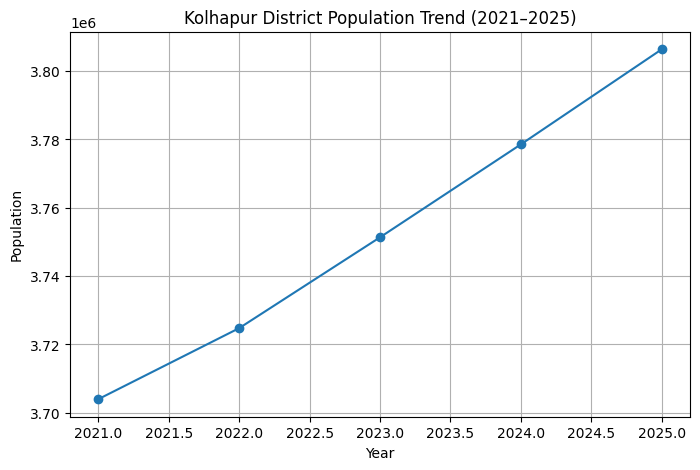

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    population_data["Year"],
    population_data["Population"],
    marker="o"
)

plt.title("Kolhapur District Population Trend (2021–2025)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True)

plt.show()

In [ ]:
# Prepare features and target

X = population_data[["Year"]]
y = population_data["Population"]

print("X:")
print(X)

print("\ny:")
print(y)

X:
   Year
0  2021
1  2022
2  2023
3  2024
4  2025

y:
0    3703979.50
1    3724773.00
2    3751369.50
3    3778581.25
4    3806416.25
Name: Population, dtype: float32


In [ ]:
# Create and train Linear Regression model

model = LinearRegression()

model.fit(X, y)

print("✅ Linear Regression model trained successfully!")
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

✅ Linear Regression model trained successfully!
Coefficient: 25868.175000000003
Intercept: -48578294.12500001


In [ ]:
# Predict population for 2026

future_year = pd.DataFrame({
    "Year": [2026]
})

predicted_population_2026 = model.predict(future_year)[0]

print("================================")
print("Kolhapur District Population Prediction")
print("================================")
print("Year:", 2026)
print(f"Predicted Population: {predicted_population_2026:,.0f}")

Kolhapur District Population Prediction
Year: 2026
Predicted Population: 3,830,628


In [ ]:
# Predict historical population values
y_pred = model.predict(X)

# Calculate evaluation metrics
mae = mean_absolute_error(y, y_pred)

rmse = np.sqrt(
    mean_squared_error(y, y_pred)
)

r2 = r2_score(y, y_pred)

print("================================")
print("MODEL EVALUATION")
print("================================")

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

MODEL EVALUATION
MAE  : 1,739.18
RMSE : 1,923.54
R²   : 0.9972


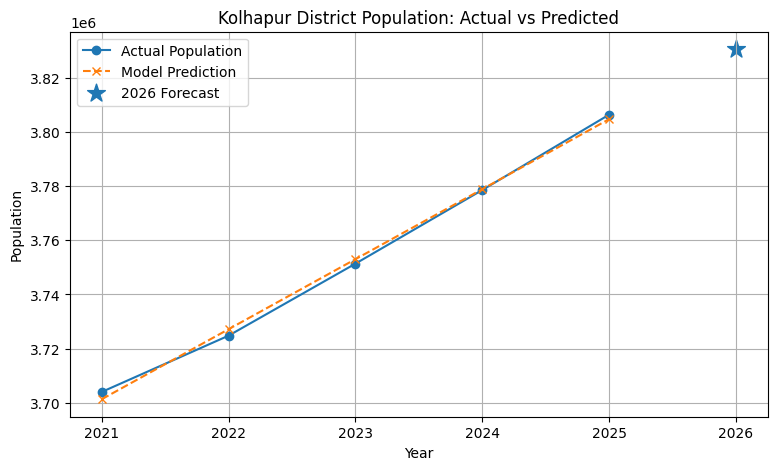

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    population_data["Year"],
    population_data["Population"],
    marker="o",
    label="Actual Population"
)

plt.plot(
    population_data["Year"],
    y_pred,
    marker="x",
    linestyle="--",
    label="Model Prediction"
)

plt.scatter(
    2026,
    predicted_population_2026,
    marker="*",
    s=180,
    label="2026 Forecast"
)

plt.title("Kolhapur District Population: Actual vs Predicted")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Time-based validation
# Train on 2021-2024 and test on 2025

train_data = population_data[population_data["Year"] < 2025]
test_data = population_data[population_data["Year"] == 2025]

X_train = train_data[["Year"]]
y_train = train_data["Population"]

X_test = test_data[["Year"]]
y_test = test_data["Population"]

# Create a new model for validation
validation_model = LinearRegression()

validation_model.fit(X_train, y_train)

# Predict 2025
y_test_pred = validation_model.predict(X_test)

# Evaluation
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("================================")
print("TIME-BASED VALIDATION")
print("================================")

print(f"Actual 2025 Population    : {y_test.iloc[0]:,.2f}")
print(f"Predicted 2025 Population : {y_test_pred[0]:,.2f}")
print(f"MAE                       : {mae_test:,.2f}")
print(f"RMSE                      : {rmse_test:,.2f}")

TIME-BASED VALIDATION
Actual 2025 Population    : 3,806,416.25
Predicted 2025 Population : 3,802,276.25
MAE                       : 4,140.00
RMSE                      : 4,140.00


In [ ]:
# ============================================
# FINAL MODEL — TRAIN ON ALL 2021–2025 DATA
# ============================================

final_model = LinearRegression()

X_final = population_data[["Year"]]
y_final = population_data["Population"]

final_model.fit(X_final, y_final)

# Predict 2026
future_year = pd.DataFrame({
    "Year": [2026]
})

final_prediction = final_model.predict(future_year)[0]

print("================================")
print("FINAL GEOVISIONAI PREDICTION")
print("================================")
print("Location: Kolhapur District, Maharashtra")
print("Training Years: 2021–2025")
print("Prediction Year: 2026")
print(f"Predicted Population: {final_prediction:,.0f}")

FINAL GEOVISIONAI PREDICTION
Location: Kolhapur District, Maharashtra
Training Years: 2021–2025
Prediction Year: 2026
Predicted Population: 3,830,628


# ============================================
# GENERALIZED DISTRICT POPULATION PREDICTION
# ============================================

In [ ]:
import requests
import geopandas as gpd
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Select location
state_name = "Maharashtra"
district_name = "Pune"

query_url = "https://mapservice.gov.in/gismapservice/rest/services/BharatMapService/Admin_Boundary_District/MapServer/1/query"

params = {
    "where": f"dtname='{district_name}' AND stname='{state_name}'",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}

response = requests.get(
    query_url,
    params=params,
    verify=False,
    timeout=60
)

print("Status Code:", response.status_code)

result = response.json()

print("Number of features:", len(result["features"]))

if len(result["features"]) > 0:

    district_boundary = gpd.GeoDataFrame.from_features(
        result["features"]
    )

    district_boundary = district_boundary.set_crs(
        "EPSG:4326",
        allow_override=True
    )

    print("District:", district_boundary.iloc[0]["dtname"])
    print("State:", district_boundary.iloc[0]["stname"])
    print("Geometry:", district_boundary.geometry.iloc[0].geom_type)
    print("Bounds:", district_boundary.total_bounds)

else:
    print("❌ District not found.")

Status Code: 200
Number of features: 1
District: Pune
State: Maharashtra
Geometry: Polygon
Bounds: [73.32283865 17.8949561  75.16280936 19.39512433]


In [ ]:
import rasterio
from rasterio.mask import mask
import numpy as np

# WorldPop 2021 raster
raster_path = "/content/ind_pop_2021_CN_100m_R2025A_v1.tif"

with rasterio.open(raster_path) as src:

    print("Raster CRS:", src.crs)
    print("Raster resolution:", src.res)

    # Pune District polygon
    shapes = [
        district_boundary.geometry.iloc[0].__geo_interface__
    ]

    # Clip raster using Pune District boundary
    clipped, transform = mask(
        src,
        shapes,
        crop=True,
        nodata=0
    )

    population = clipped[0]

    # Keep valid population pixels
    valid_population = population[population > 0]

    # Calculate total population
    pune_population_2021 = valid_population.sum()

print("\n================================")
print("Pune District Population 2021")
print("================================")
print(f"{pune_population_2021:,.2f}")

Raster CRS: EPSG:4326
Raster resolution: (0.00083333333, 0.00083333333)

Pune District Population 2021
14,565,177.00


In [ ]:
def extract_population_from_raster(raster_path, district_gdf):

    with rasterio.open(raster_path) as src:

        shapes = [
            district_gdf.geometry.iloc[0].__geo_interface__
        ]

        clipped, transform = mask(
            src,
            shapes,
            crop=True,
            nodata=0
        )

        population = clipped[0]

        valid_population = population[population > 0]

        total_population = valid_population.sum()

    return total_population

In [ ]:
pune_2021 = extract_population_from_raster(
    "/content/ind_pop_2021_CN_100m_R2025A_v1.tif",
    district_boundary
)

print(f"Pune District Population 2021: {pune_2021:,.2f}")

Pune District Population 2021: 14,565,177.00


In [ ]:
years = [2021, 2022, 2023, 2024, 2025]

population_data = []

for year in years:

    raster_path = f"/content/ind_pop_{year}_CN_100m_R2025A_v1.tif"

    population = extract_population_from_raster(
        raster_path,
        district_boundary
    )

    population_data.append({
        "Year": year,
        "Population": population
    })

    print(f"{year}: {population:,.2f}")

pune_population_df = pd.DataFrame(population_data)

print("\n================================")
print("Pune District Population Dataset")
print("================================")

display(pune_population_df)

2021: 14,565,177.00
2022: 14,661,756.00
2023: 14,785,778.00
2024: 14,911,732.00
2025: 15,040,615.00

Pune District Population Dataset


,Year,Population
0,2021,14565177.0
1,2022,14661756.0
2,2023,14785778.0
3,2024,14911732.0
4,2025,15040615.0


In [ ]:
# Prepare data for Machine Learning

X = pune_population_df[["Year"]]
y = pune_population_df["Population"]

print("X:")
display(X)

print("\ny:")
display(y)

X:


,Year
0,2021
1,2022
2,2023
3,2024
4,2025



y:


,Population
0,14565177.0
1,14661756.0
2,14785778.0
3,14911732.0
4,15040615.0


In [ ]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
pune_model = LinearRegression()

# Train the model
pune_model.fit(X, y)

print("✅ Pune Linear Regression model trained successfully!")

print("Coefficient:", pune_model.coef_[0])
print("Intercept:", pune_model.intercept_)

✅ Pune Linear Regression model trained successfully!
Coefficient: 120085.20000000003
Intercept: -228139348.00000006


In [ ]:
# Predict Pune District population for 2026

future_year = pd.DataFrame({"Year": [2026]})

predicted_2026 = pune_model.predict(future_year)[0]

print("================================")
print("Pune District Population Prediction")
print("================================")
print("Year:", 2026)
print(f"Predicted Population: {predicted_2026:,.0f}")

Pune District Population Prediction
Year: 2026
Predicted Population: 15,153,267


In [ ]:
# ============================================
# PUNE TIME-BASED VALIDATION
# Train: 2021–2024
# Test:  2025
# ============================================

train_data = pune_population_df[pune_population_df["Year"] < 2025]
test_data = pune_population_df[pune_population_df["Year"] == 2025]

X_train = train_data[["Year"]]
y_train = train_data["Population"]

X_test = test_data[["Year"]]
y_test = test_data["Population"]

# Create validation model
pune_validation_model = LinearRegression()

# Train using only 2021–2024
pune_validation_model.fit(X_train, y_train)

# Predict 2025
y_pred = pune_validation_model.predict(X_test)

print("================================")
print("PUNE TIME-BASED VALIDATION")
print("================================")

print(f"Actual 2025 Population    : {y_test.iloc[0]:,.2f}")
print(f"Predicted 2025 Population : {y_pred[0]:,.2f}")

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE                       : {mae:,.2f}")
print(f"RMSE                      : {rmse:,.2f}")

PUNE TIME-BASED VALIDATION
Actual 2025 Population    : 15,040,615.00
Predicted 2025 Population : 15,022,032.50
MAE                       : 18,582.50
RMSE                      : 18,582.50


ALL India district boundaries

In [ ]:
import requests
import geopandas as gpd
import urllib3
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

query_url = "https://mapservice.gov.in/gismapservice/rest/services/BharatMapService/Admin_Boundary_District/MapServer/1/query"

# Maharashtra only for our first test
params = {
    "where": "stname='Maharashtra'",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}

response = requests.get(
    query_url,
    params=params,
    verify=False,
    timeout=120
)

print("Status Code:", response.status_code)

result = response.json()

print("Number of Maharashtra districts:", len(result["features"]))

maharashtra_districts = gpd.GeoDataFrame.from_features(
    result["features"]
)

maharashtra_districts = maharashtra_districts.set_crs(
    "EPSG:4326",
    allow_override=True
)

print("\nColumns:")
print(maharashtra_districts.columns.tolist())

print("\nFirst 10 districts:")
print(
    maharashtra_districts[
        ["stname", "dtname"]
    ].head(10).to_string(index=False)
)

print("\nCRS:", maharashtra_districts.crs)

Status Code: 200
Number of Maharashtra districts: 36

Columns:
['geometry', 'OBJECTID', 'dtname', 'stname', 'stcode11', 'dtcode11', 'year_stat', 'dist_lgd', 'state_lgd', 'SHAPE_Length', 'SHAPE_Area', 'remarks', 'd_pan_code', 'd_pan_name', 'New_Name', 'mached']

First 10 districts:
     stname                    dtname
Maharashtra               Ahilyanagar
Maharashtra                     Akola
Maharashtra                  Amravati
Maharashtra Chhatrapati Sambhajinagar
Maharashtra                  Bhandara
Maharashtra                      Beed
Maharashtra                  Buldhana
Maharashtra                Chandrapur
Maharashtra                     Dhule
Maharashtra                Gadchiroli

CRS: EPSG:4326


In [ ]:
import os

print("Files in /content:")
for file in os.listdir("/content"):
    if file.endswith(".tif"):
        print(file)

Files in /content:


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/GeoVisionAI"

DATA_DIR = os.path.join(PROJECT_DIR, "datasets")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("✅ GeoVisionAI project folders created!")
print("Project:", PROJECT_DIR)
print("Datasets:", DATA_DIR)
print("Results:", RESULTS_DIR)

✅ GeoVisionAI project folders created!
Project: /content/drive/MyDrive/GeoVisionAI
Datasets: /content/drive/MyDrive/GeoVisionAI/datasets
Results: /content/drive/MyDrive/GeoVisionAI/results


In [ ]:
import requests
import os

years = [2021, 2022, 2023, 2024, 2025]

for year in years:

    filename = f"ind_pop_{year}_CN_100m_R2025A_v1.tif"

    url = (
        f"https://data.worldpop.org/GIS/Population/"
        f"Global_2015_2030/R2025A/{year}/IND/v1/100m/"
        f"constrained/{filename}"
    )

    output_file = os.path.join(DATA_DIR, filename)

    # Skip if already downloaded
    if os.path.exists(output_file):
        print(f"✅ {year} already exists — skipping")
        continue

    print(f"\nDownloading WorldPop India {year}...")

    with requests.get(url, stream=True) as response:

        response.raise_for_status()

        total_size = int(
            response.headers.get("content-length", 0)
        )

        downloaded = 0

        with open(output_file, "wb") as f:

            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):

                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)

                    if total_size:
                        percent = downloaded / total_size * 100
                        print(
                            f"\rDownloaded: {percent:.1f}%",
                            end=""
                        )

    print(f"\n✅ {year} saved to Google Drive")

print("\n🎉 ALL REQUESTED DATASETS ARE READY!")

NameError: name 'DATA_DIR' is not defined

In [ ]:
import os

print("Files currently in GeoVisionAI/datasets:\n")

if os.path.exists(DATA_DIR):
    files = os.listdir(DATA_DIR)

    if files:
        for f in files:
            size = os.path.getsize(
                os.path.join(DATA_DIR, f)
            ) / (1024**3)

            print(f"{f}  →  {size:.2f} GB")
    else:
        print("Folder is empty.")
else:
    print("Dataset folder not found.")

Files currently in GeoVisionAI/datasets:



NameError: name 'DATA_DIR' is not defined

In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/GeoVisionAI"

DATA_DIR = os.path.join(PROJECT_DIR, "datasets")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("✅ Variables restored!")
print("Dataset folder:", DATA_DIR)
print("Results folder:", RESULTS_DIR)

✅ Variables restored!
Dataset folder: /content/drive/MyDrive/GeoVisionAI/datasets
Results folder: /content/drive/MyDrive/GeoVisionAI/results


In [ ]:
print("Files currently in GeoVisionAI/datasets:\n")

files = os.listdir(DATA_DIR)

if files:
    for f in files:
        size = os.path.getsize(
            os.path.join(DATA_DIR, f)
        ) / (1024**3)

        print(f"{f} → {size:.2f} GB")
else:
    print("Folder is empty.")

Files currently in GeoVisionAI/datasets:

Folder is empty.


In [ ]:
import requests
import os

year = 2021

filename = f"ind_pop_{year}_CN_100m_R2025A_v1.tif"

url = (
    f"https://data.worldpop.org/GIS/Population/"
    f"Global_2015_2030/R2025A/{year}/IND/v1/100m/"
    f"constrained/{filename}"
)

output_file = os.path.join(DATA_DIR, filename)

print("Downloading WorldPop 2021...")
print("Destination:", output_file)

response = requests.get(
    url,
    stream=True,
    timeout=120
)

response.raise_for_status()

total_size = int(
    response.headers.get("content-length", 0)
)

downloaded = 0

with open(output_file, "wb") as f:

    for chunk in response.iter_content(
        chunk_size=4 * 1024 * 1024
    ):

        if chunk:
            f.write(chunk)
            downloaded += len(chunk)

            if total_size:
                percent = downloaded / total_size * 100
                print(
                    f"\rDownloaded: {percent:.1f}%",
                    end=""
                )

print("\n\n✅ 2021 download completed!")

Destination: /content/drive/MyDrive/GeoVisionAI/datasets/ind_pop_2021_CN_100m_R2025A_v1.tif
Downloaded: 100.0%

✅ 2021 download completed!


In [ ]:
import os
import rasterio

raster_2021 = os.path.join(
    DATA_DIR,
    "ind_pop_2021_CN_100m_R2025A_v1.tif"
)

print("File exists:", os.path.exists(raster_2021))

if os.path.exists(raster_2021):

    size_gb = os.path.getsize(raster_2021) / (1024**3)

    print(f"File size: {size_gb:.2f} GB")

    with rasterio.open(raster_2021) as src:

        print("CRS:", src.crs)
        print("Resolution:", src.res)
        print("Width:", src.width)
        print("Height:", src.height)
        print("NoData:", src.nodata)

    print("\n✅ 2021 WorldPop raster is valid!")

else:
    print("❌ File not found.")

File exists: True
File size: 0.71 GB
CRS: EPSG:4326
Resolution: (0.00083333333, 0.00083333333)
Width: 35040
Height: 34507
NoData: -99999.0

✅ 2021 WorldPop raster is valid!


In [ ]:
import requests
import os

year = 2022

filename = f"ind_pop_{year}_CN_100m_R2025A_v1.tif"

url = (
    f"https://data.worldpop.org/GIS/Population/"
    f"Global_2015_2030/R2025A/{year}/IND/v1/100m/"
    f"constrained/{filename}"
)

output_file = os.path.join(DATA_DIR, filename)

print("Downloading WorldPop 2022...")
print("Destination:", output_file)

response = requests.get(
    url,
    stream=True,
    timeout=120
)

response.raise_for_status()

total_size = int(
    response.headers.get("content-length", 0)
)

downloaded = 0

with open(output_file, "wb") as f:

    for chunk in response.iter_content(
        chunk_size=4 * 1024 * 1024
    ):

        if chunk:
            f.write(chunk)
            downloaded += len(chunk)

            if total_size:
                percent = downloaded / total_size * 100
                print(
                    f"\rDownloaded: {percent:.1f}%",
                    end=""
                )

print("\n\n✅ 2022 download completed!")

Destination: /content/drive/MyDrive/GeoVisionAI/datasets/ind_pop_2022_CN_100m_R2025A_v1.tif
Downloaded: 54.1%

KeyboardInterrupt: 

In [ ]:
import os

file_2022 = os.path.join(
    DATA_DIR,
    "ind_pop_2022_CN_100m_R2025A_v1.tif"
)

if os.path.exists(file_2022):
    size_gb = os.path.getsize(file_2022) / (1024**3)
    print(f"Current 2022 file size: {size_gb:.2f} GB")
else:
    print("2022 file does not exist.")

Current 2022 file size: 0.39 GB


In [ ]:
import os
import requests

year = 2022

filename = f"ind_pop_{year}_CN_100m_R2025A_v1.tif"

url = (
    f"https://data.worldpop.org/GIS/Population/"
    f"Global_2015_2030/R2025A/{year}/IND/v1/100m/"
    f"constrained/{filename}"
)

output_file = os.path.join(DATA_DIR, filename)

existing_size = os.path.getsize(output_file)

print(f"Existing partial file: {existing_size / (1024**3):.2f} GB")
print("Resuming download...")

headers = {
    "Range": f"bytes={existing_size}-"
}

response = requests.get(
    url,
    headers=headers,
    stream=True,
    timeout=120
)

print("HTTP status:", response.status_code)

# 206 means the server accepted our resume request
if response.status_code != 206:
    print("⚠️ Server did not provide a partial response.")
    response.close()
else:

    total_remaining = int(
        response.headers.get("content-length", 0)
    )

    downloaded = existing_size

    with open(output_file, "ab") as f:

        for chunk in response.iter_content(
            chunk_size=4 * 1024 * 1024
        ):

            if chunk:
                f.write(chunk)
                downloaded += len(chunk)

                if total_remaining:
                    percent = (
                        (downloaded - existing_size)
                        / total_remaining
                    ) * 100

                    print(
                        f"\rAdditional download: {percent:.1f}%",
                        end=""
                    )

    print("\n\n✅ 2022 download completed!")

Existing partial file: 0.39 GB
Resuming download...
HTTP status: 200
⚠️ Server did not provide a partial response.


In [ ]:
!wget -c -O "/content/drive/MyDrive/GeoVisionAI/datasets/ind_pop_2022_CN_100m_R2025A_v1.tif" \
"https://data.worldpop.org/GIS/Population/Global_2015_2030/R2025A/2022/IND/v1/100m/constrained/ind_pop_2022_CN_100m_R2025A_v1.tif"

--2026-08-13 07:47:52--  https://data.worldpop.org/GIS/Population/Global_2015_2030/R2025A/2022/IND/v1/100m/constrained/ind_pop_2022_CN_100m_R2025A_v1.tif
Resolving data.worldpop.org (data.worldpop.org)... 152.78.118.157, ::ffff:152.78.118.157
Connecting to data.worldpop.org (data.worldpop.org)|152.78.118.157|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 767648789 (732M) [image/tiff]
Saving to: ‘/content/drive/MyDrive/GeoVisionAI/datasets/ind_pop_2022_CN_100m_R2025A_v1.tif’

          /content/  42%[=======>            ] 312.20M  1.22MB/s    eta 5m 43s ^C


In [ ]:
import requests
import os

year = 2022

filename = f"ind_pop_{year}_CN_100m_R2025A_v1.tif"

url = (
    f"https://data.worldpop.org/GIS/Population/"
    f"Global_2015_2030/R2025A/{year}/IND/v1/100m/"
    f"constrained/{filename}"
)

output_file = os.path.join(DATA_DIR, filename)

print("Downloading WorldPop 2022...")
print("Destination:", output_file)

response = requests.get(
    url,
    stream=True,
    timeout=120
)

response.raise_for_status()

total_size = int(
    response.headers.get("content-length", 0)
)

downloaded = 0

with open(output_file, "wb") as f:

    for chunk in response.iter_content(
        chunk_size=4 * 1024 * 1024
    ):

        if chunk:
            f.write(chunk)
            downloaded += len(chunk)

            if total_size:
                percent = downloaded / total_size * 100
                print(
                    f"\rDownloaded: {percent:.1f}%",
                    end=""
                )

print("\n\n✅ 2022 download completed!")

Destination: /content/drive/MyDrive/GeoVisionAI/datasets/ind_pop_2022_CN_100m_R2025A_v1.tif
Downloaded: 100.0%

✅ 2022 download completed!


In [ ]:
import os
import rasterio

raster_2022 = os.path.join(
    DATA_DIR,
    "ind_pop_2022_CN_100m_R2025A_v1.tif"
)

print("File exists:", os.path.exists(raster_2022))

if os.path.exists(raster_2022):

    size_gb = os.path.getsize(raster_2022) / (1024**3)

    print(f"File size: {size_gb:.2f} GB")

    with rasterio.open(raster_2022) as src:

        print("CRS:", src.crs)
        print("Resolution:", src.res)
        print("Width:", src.width)
        print("Height:", src.height)
        print("NoData:", src.nodata)

    print("\n✅ 2022 WorldPop raster is valid!")

else:
    print("❌ File not found.")

File exists: True
File size: 0.71 GB
CRS: EPSG:4326
Resolution: (0.00083333333, 0.00083333333)
Width: 35040
Height: 34507
NoData: -99999.0

✅ 2022 WorldPop raster is valid!


In [ ]:
import requests
import os

year = 2023

filename = f"ind_pop_{year}_CN_100m_R2025A_v1.tif"

url = (
    f"https://data.worldpop.org/GIS/Population/"
    f"Global_2015_2030/R2025A/{year}/IND/v1/100m/"
    f"constrained/{filename}"
)

output_file = os.path.join(DATA_DIR, filename)

print("Downloading WorldPop 2023...")
print("Destination:", output_file)

response = requests.get(
    url,
    stream=True,
    timeout=120
)

response.raise_for_status()

total_size = int(
    response.headers.get("content-length", 0)
)

downloaded = 0

with open(output_file, "wb") as f:

    for chunk in response.iter_content(
        chunk_size=4 * 1024 * 1024
    ):

        if chunk:
            f.write(chunk)
            downloaded += len(chunk)

            if total_size:
                percent = downloaded / total_size * 100
                print(
                    f"\rDownloaded: {percent:.1f}%",
                    end=""
                )

print("\n\n✅ 2023 download completed!")

Destination: /content/drive/MyDrive/GeoVisionAI/datasets/ind_pop_2023_CN_100m_R2025A_v1.tif
Downloaded: 100.0%

✅ 2023 download completed!


In [ ]:
import os
import rasterio

raster_2023 = os.path.join(
    DATA_DIR,
    "ind_pop_2023_CN_100m_R2025A_v1.tif"
)

print("File exists:", os.path.exists(raster_2023))

if os.path.exists(raster_2023):

    size_gb = os.path.getsize(raster_2023) / (1024**3)

    print(f"File size: {size_gb:.2f} GB")

    with rasterio.open(raster_2023) as src:

        print("CRS:", src.crs)
        print("Resolution:", src.res)
        print("Width:", src.width)
        print("Height:", src.height)
        print("NoData:", src.nodata)

    print("\n✅ 2023 WorldPop raster is valid!")

else:
    print("❌ File not found.")

File exists: True
File size: 0.72 GB
CRS: EPSG:4326
Resolution: (0.00083333333, 0.00083333333)
Width: 35040
Height: 34507
NoData: -99999.0

✅ 2023 WorldPop raster is valid!


In [ ]:
import requests
import os

year = 2024

filename = f"ind_pop_{year}_CN_100m_R2025A_v1.tif"

url = (
    f"https://data.worldpop.org/GIS/Population/"
    f"Global_2015_2030/R2025A/{year}/IND/v1/100m/"
    f"constrained/{filename}"
)

output_file = os.path.join(DATA_DIR, filename)

print("Downloading WorldPop 2024...")
print("Destination:", output_file)

response = requests.get(
    url,
    stream=True,
    timeout=120
)

response.raise_for_status()

total_size = int(
    response.headers.get("content-length", 0)
)

downloaded = 0

with open(output_file, "wb") as f:

    for chunk in response.iter_content(
        chunk_size=4 * 1024 * 1024
    ):
        if chunk:
            f.write(chunk)
            downloaded += len(chunk)

            if total_size:
                percent = downloaded / total_size * 100
                print(
                    f"\rDownloaded: {percent:.1f}%",
                    end=""
                )

print("\n\n✅ 2024 download completed!")

Destination: /content/drive/MyDrive/GeoVisionAI/datasets/ind_pop_2024_CN_100m_R2025A_v1.tif
Downloaded: 100.0%

✅ 2024 download completed!


In [ ]:
import os
import rasterio

raster_2024 = os.path.join(
    DATA_DIR,
    "ind_pop_2024_CN_100m_R2025A_v1.tif"
)

print("File exists:", os.path.exists(raster_2024))

if os.path.exists(raster_2024):

    size_gb = os.path.getsize(raster_2024) / (1024**3)

    print(f"File size: {size_gb:.2f} GB")

    with rasterio.open(raster_2024) as src:
        print("CRS:", src.crs)
        print("Resolution:", src.res)
        print("Width:", src.width)
        print("Height:", src.height)
        print("NoData:", src.nodata)

    print("\n✅ 2024 WorldPop raster is valid!")

else:
    print("❌ File not found.")

File exists: True
File size: 0.72 GB
CRS: EPSG:4326
Resolution: (0.00083333333, 0.00083333333)
Width: 35040
Height: 34507
NoData: -99999.0

✅ 2024 WorldPop raster is valid!


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_DIR = "/content/drive/MyDrive/GeoVisionAI"

DATA_DIR = os.path.join(PROJECT_DIR, "datasets")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("✅ GeoVisionAI paths restored!")
print("Dataset folder:", DATA_DIR)

✅ GeoVisionAI paths restored!
Dataset folder: /content/drive/MyDrive/GeoVisionAI/datasets


In [3]:
import os

print("Files in GeoVisionAI/datasets:\n")

for f in sorted(os.listdir(DATA_DIR)):
    size = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"{f} → {size:.2f} GB")

Files in GeoVisionAI/datasets:

ind_pop_2021_CN_100m_R2025A_v1.tif → 0.71 GB
ind_pop_2022_CN_100m_R2025A_v1.tif → 0.01 GB


In [4]:
import os

print("FULL DATASET FOLDER CONTENTS:")
print("=" * 60)

for f in os.listdir(DATA_DIR):
    path = os.path.join(DATA_DIR, f)
    size_mb = os.path.getsize(path) / (1024**2)

    print(f"{f}")
    print(f"   Size: {size_mb:.2f} MB")
    print()

FULL DATASET FOLDER CONTENTS:
ind_pop_2021_CN_100m_R2025A_v1.tif
   Size: 728.76 MB

ind_pop_2022_CN_100m_R2025A_v1.tif
   Size: 9.00 MB

